In [87]:
import sys
from pathlib import Path
sys.path.append("/export/home/mickler/boa")

import os
os.environ["PROJECT_ROOT"] = "/export/home/mickler/boa"

import hydra
from hydra import initialize, compose
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import torch

# Monkey patch the HydraConfig.get method to avoid the error
from hydra.core.hydra_config import HydraConfig

# Store the original method before patching
_original_get = HydraConfig.get.__func__

@classmethod 
def patched_get(cls):
    try:
        instance = cls.instance()
        if instance.cfg is None:
            raise ValueError("HydraConfig was not set")
        return instance.cfg.hydra
    except ValueError:
        # Return a minimal mock config when HydraConfig is not set
        from omegaconf import DictConfig
        mock_config = DictConfig({
            "job": {
                "override_dirname": "",
                "num": "0"
            },
            "runtime": {
                "output_dir": "/tmp/hydra_fallback"
            },
            "sweep": {
                "dir": "/tmp/hydra_sweep"
            }
        })
        return mock_config

# Apply the monkey patch
HydraConfig.get = patched_get

# Import and register the custom resolvers from your project
from boa.utils.omegaconf_resolvers import *

from boa.model.module import ChgLightningModule

run_path = Path("/export/scratch/mklockow/boa/models/train/runs/437_qm9_small_qm9_vasp_small__seed-2")
best_ckpt = (run_path / "best_model_path.txt").read_text().strip()
model_path = run_path / best_ckpt
config_path = run_path / "config.yaml"

# cfg = OmegaConf.load(config_path)

with initialize(config_path="../configs", version_base="1.1"):
    cfg = compose(config_name="train.yaml", overrides=["data=md", "data.datamodule.dataset.mol_name=benzene", "data.datamodule.dataset.n_probe=null", "data.basis_info.basis=def2-svp"]) # def2-svp

# First instantiate datamodule to get metadata
datamodule = hydra.utils.instantiate(cfg.data.datamodule, _recursive_=False)
datamodule.setup("fit")  # This creates the metadata
metadata = datamodule.metadata

print(f"Metadata: {metadata}")

# Now instantiate model with proper metadata
model = hydra.utils.instantiate(cfg.model, train=cfg, _recursive_=False, metadata=metadata)
# model = ChgLightningModule.load_from_checkpoint(model_path, map_location="cpu")

/export/home/mickler/boa/.venv/lib/python3.11/site-packages/IPython/core/async_helpers.py:128: UserWarning: 
'hydra/launcher/basic' is validated against ConfigStore schema with the same name.
This behavior is deprecated in Hydra 1.1 and will be removed in Hydra 1.2.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/automatic_schema_matching for migration instructions.
  coro.send(None)


Precomputing train density from FFT coefficients ...
Precomputing test density from FFT coefficients ...
Precomputing test density from FFT coefficients ...
Metadata: {'target_mean': 0.04942677915096283, 'target_var': 0.09023565798997879, 'avg_num_neighbors': 3, 'unique_atom_types': [1, 6]}
Unique atom types: [1 6]
Using radial correction for GTOs.
Using radial correction for GTOs.
Metadata: {'target_mean': 0.04942677915096283, 'target_var': 0.09023565798997879, 'avg_num_neighbors': 3, 'unique_atom_types': [1, 6]}
Unique atom types: [1 6]
Using radial correction for GTOs.
Using radial correction for GTOs.


/export/home/mickler/boa/boa/model/module.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(gto.contraction, dtype=torch.int64),


BOA(
  (boa_stack): BoaBlockStack(
    (blocks): ModuleList(
      (0-3): 4 x BoaBlock(
        (linear0): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNodeOperatorAtom(
              (linear1): Linear(4x0e+1x1o -> 4x0e+1x1o | 17 weights)
            )
            (6): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+1x2e -> 7x0e+4x1o+1x2e | 66 weights)
            )
          )
        )
        (linear1): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNodeOperatorAtom(
              (linear1): Linear(4x0e+1x1o -> 4x0e+1x1o | 17 weights)
            )
            (6): StableLinearNodeOperatorAtom(
              (linear1): Linear(7x0e+4x1o+1x2e -> 7x0e+4x1o+1x2e | 66 weights)
            )
          )
        )
        (linear2): StableLinearNodeOperator(
          (stable_linear_node_operators): ModuleDict(
            (1): StableLinearNo

In [88]:
# datamodule.setup("fit")  # Already called in the first cell
val_set = datamodule.val_dataset
sample = val_set[0]
print(sample)

OFData(
  pos=[12, 3],
  atomic_numbers=[12],
  coeffs=[186],
  atom_ind=[12],
  n_basis_per_atom=[12],
  atom_ptr=[12],
  basis_function_ind=[186],
  coeff_ind_to_node_ind=[186],
  dual_basis_integrals=[186],
  irreps_per_atom=[12],
  representations={
    pos=Representation.NONE,
    atomic_numbers=Representation.NONE,
    coeffs=Representation.VECTOR,
    ground_state_coeffs=Representation.VECTOR,
    gradient_label=Representation.GRADIENT,
    energy_label=Representation.SCALAR,
    has_energy_label=Representation.NONE,
    atom_ind=Representation.NONE,
    n_basis_per_atom=Representation.NONE,
    atom_ptr=Representation.NONE,
    basis_function_ind=Representation.NONE,
    coeff_ind_to_node_ind=Representation.NONE,
    dual_basis_integrals=Representation.DUAL_VECTOR,
    mol_id=Representation.NONE,
    scf_iteration=Representation.NONE,
    irreps_per_atom=Representation.NONE,
    representations=Representation.NONE,
    n_probe=Representation.NONE,
    cell=Representation.VECTOR

In [89]:
import pyvista as pv

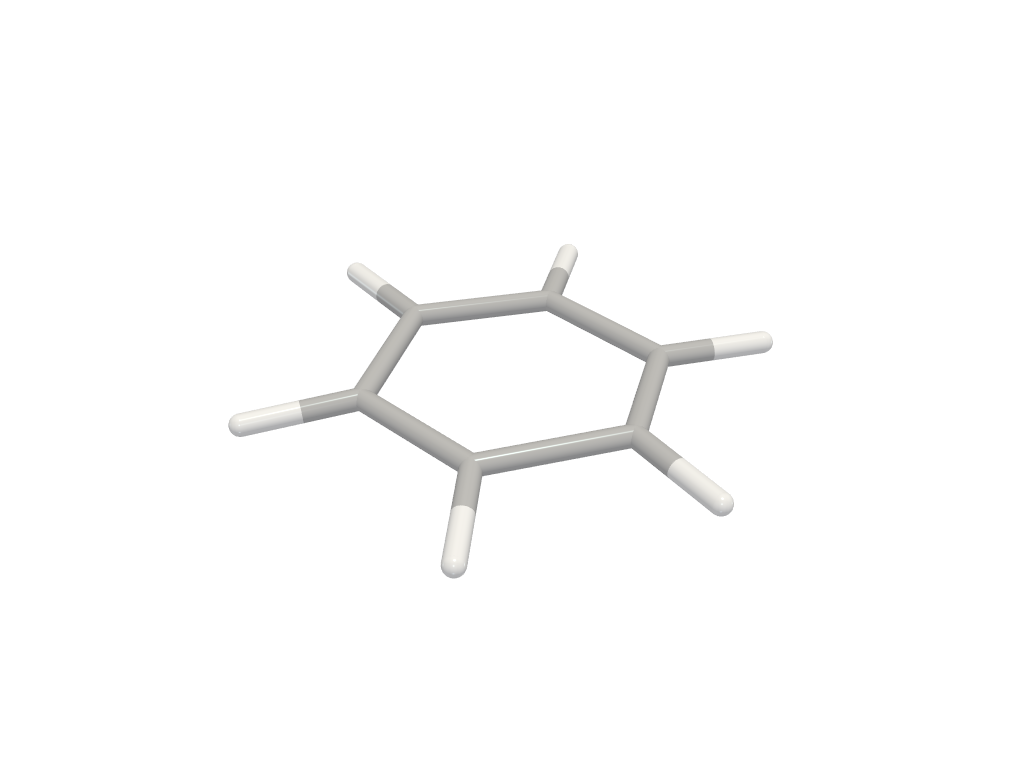

In [90]:
import pyvista as pv
from mldft.utils.visualize_3d import get_sticks_mesh_dict
from mldft.utils.molecules import build_molecule_ofdata

# Switch to static backend for better sphere rendering in notebooks
pv.set_jupyter_backend('static')  # Use static backend for notebooks
# pv.set_jupyter_backend('html')    # Interactive with panel
# pv.set_jupyter_backend('trame')    # Interactive with trame
# pv.set_jupyter_backend('pythreejs') # Interactive with pythreejs

mol = build_molecule_ofdata(sample)

pl = pv.Plotter(notebook=True)
pl.add_mesh(**get_sticks_mesh_dict(mol))
pl.show()

In [191]:
model.gto_dict

ModuleDict(
  (1): GTOs(Lmax=1, n_orbitals=5, n_contracted=5.0, outdim=7)
  (6): GTOs(Lmax=2, n_orbitals=12, n_contracted=12.0, outdim=24)
)

In [92]:
import numpy as np
from scipy.spatial.distance import cdist

def compute_gaussian_product_peaks(sample, gto_dict, min_distance_threshold=0.1):
    """
    Compute the peaks of Gaussian products for neighboring atoms within cutoff.
    
    When two Gaussians exp(-α₁|r-R₁|²) and exp(-α₂|r-R₂|²) are multiplied,
    the product is a Gaussian with peak at: R_peak = (α₁R₁ + α₂R₂)/(α₁ + α₂)
    
    Args:
        sample: Molecule data containing positions, atomic numbers, edge_index
        gto_dict: Dictionary of GTOs for each atom type
        min_distance_threshold: Minimum distance between peaks to avoid duplicates
    
    Returns:
        peak_coords: Tensor of shape (N_peaks, 3) with peak coordinates
        peak_info: List of dictionaries with metadata for each peak
    """
    
    # Get molecular information
    atomic_numbers = sample.atomic_numbers
    positions = sample.pos
    edge_index = sample.edge_index
    
    # Store all peaks and their metadata
    all_peaks = []
    peak_info = []
    
    # Process each edge (atom pair)
    for edge_idx in range(edge_index.shape[1]):
        atom_i_idx = edge_index[0, edge_idx].item()
        atom_j_idx = edge_index[1, edge_idx].item()
        
        # Skip self-loops for now (we could include them for completeness)
        if atom_i_idx == atom_j_idx:
            continue
            
        atom_i_type = atomic_numbers[atom_i_idx].item()
        atom_j_type = atomic_numbers[atom_j_idx].item()
        
        pos_i = positions[atom_i_idx]
        pos_j = positions[atom_j_idx]
        
        # Check if atoms are within cutoff distance
        distance = torch.norm(pos_i - pos_j).item()
        
        # Get GTOs for both atoms
        gto_i = gto_dict[str(atom_i_type)]
        gto_j = gto_dict[str(atom_j_type)]
        
        if distance > max(gto_i.cutoff, gto_j.cutoff):
            continue
            
        # Get exponents for both atoms
        expos_i = gto_i.expos
        expos_j = gto_j.expos
        
        # Compute peaks for all combinations of basis functions
        for k, exp_i in enumerate(expos_i):
            for l, exp_j in enumerate(expos_j):
                # Peak of product of two Gaussians: weighted average of centers
                alpha_i = exp_i.item()
                alpha_j = exp_j.item()
                
                # Peak position: (α₁R₁ + α₂R₂)/(α₁ + α₂)
                peak_pos = (alpha_i * pos_i + alpha_j * pos_j) / (alpha_i + alpha_j)
                
                # Store peak information
                peak_info_dict = {
                    'atom_i_idx': atom_i_idx,
                    'atom_j_idx': atom_j_idx,
                    'atom_i_type': atom_i_type,
                    'atom_j_type': atom_j_type,
                    'atom_i_pos': pos_i.clone(),
                    'atom_j_pos': pos_j.clone(),
                    'basis_i_idx': k,
                    'basis_j_idx': l,
                    'exp_i': alpha_i,
                    'exp_j': alpha_j,
                    'distance': distance,
                    'peak_pos': peak_pos.clone()
                }
                
                all_peaks.append(peak_pos)
                peak_info.append(peak_info_dict)
    
    if not all_peaks:
        return torch.empty(0, 3), []
    
    # Convert to tensor
    peak_coords = torch.stack(all_peaks)
    
    # Remove duplicates that are too close together
    if min_distance_threshold > 0:
        unique_peaks = []
        unique_info = []
        
        for i, (peak, info) in enumerate(zip(peak_coords, peak_info)):
            is_duplicate = False
            for existing_peak in unique_peaks:
                if torch.norm(peak - existing_peak) < min_distance_threshold:
                    is_duplicate = True
                    break
            
            if not is_duplicate:
                unique_peaks.append(peak)
                unique_info.append(info)
        
        if unique_peaks:
            peak_coords = torch.stack(unique_peaks)
            peak_info = unique_info
        else:
            peak_coords = torch.empty(0, 3)
            peak_info = []
    
    return peak_coords, peak_info

# Test the function
peaks, peak_info = compute_gaussian_product_peaks(sample, model.gto_dict, min_distance_threshold=0)
print(f"Found {len(peaks)} unique Gaussian product peaks")
print(f"Peak coordinates shape: {peaks.shape}")

Found 6780 unique Gaussian product peaks
Peak coordinates shape: torch.Size([6780, 3])


In [199]:
def get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=20):
    """
    Create an atoms-only representation for a molecule (no bonds).
    
    Args:
        sample: Molecule data containing positions and atomic numbers
        atom_radius: The radius of the spheres representing atoms
        resolution: The resolution of the spheres
        
    Returns:
        A dictionary with keyword arguments to pass to pyvista.Plotter.add_mesh
    """
    # Color mapping for atoms
    ATOM_COLORS = {
        1: "#eeeeee",   # H - white
        6: "#555555",   # C - gray
        7: "#8f8fff",   # N - blue
        8: "#f00000",   # O - red
        9: "#ffff00",   # F - yellow
        15: "#ffa500",  # P - orange
        16: "#ffc832",  # S - yellow
        19: "#42f4ee",  # K - cyan
        0: "#3f3f3f",   # Unknown - dark gray
    }
    
    # Get positions and atomic numbers directly from sample
    positions = sample.pos  # Already in Bohr
    atomic_numbers = sample.atomic_numbers
    
    mesh_elements = []
    
    # Create spheres for atoms only
    for i, (pos, atomic_num) in enumerate(zip(positions, atomic_numbers)):
        atomic_num = atomic_num.item()
        color_id = list(ATOM_COLORS.keys()).index(atomic_num) if atomic_num in ATOM_COLORS else list(ATOM_COLORS.keys()).index(0)
        
        sphere = pv.Sphere(
            center=pos.numpy(),
            radius=atom_radius,
            phi_resolution=resolution,
            theta_resolution=resolution,
        )
        sphere["color_ids"] = np.ones(sphere.n_cells) * color_id
        mesh_elements.append(sphere)
    
    merged_mesh = pv.MultiBlock(mesh_elements).combine().extract_surface()
    add_mesh_kwargs = dict(
        mesh=merged_mesh,
        smooth_shading=True,
        diffuse=0.5,
        specular=0.5,
        ambient=0.5,
        clim=(0, len(ATOM_COLORS)-1),
        cmap=list(ATOM_COLORS.values()),
        show_scalar_bar=False,
    )
    return add_mesh_kwargs

def find_isosurface_value(cube_array, quantile=0.9, p=2):
    """Find an isosurface value for a cube array, such that the isosurface contains a given
    fraction of the total mass. Adapted from visualize_3d.py"""
    cube_array = np.abs(cube_array).flatten()
    mass = cube_array**p
    total_mass = mass.sum()
    mass_sorted = np.sort(mass)[::-1]
    ind = np.searchsorted(np.cumsum(mass_sorted), total_mass * quantile)
    isosurface_value = mass_sorted[ind] ** (1 / p)
    return isosurface_value

def compute_gaussian_product_3d(peak_info_single, gto_dict, grid_resolution=50, extent=3.0, use_all_orbitals=False):
    """
    Compute the 3D Gaussian product function on a grid around the peak using full GTOs.
    
    Args:
        peak_info_single: Single peak info dictionary
        gto_dict: Dictionary of GTOs for each atom type
        grid_resolution: Number of grid points in each dimension
        extent: Half-size of the grid in Bohr
        use_all_orbitals: If True, sum over all orbitals for each radial function.
                         If False, use the maximum component (for visualization)
        
    Returns:
        grid: PyVista structured grid with Gaussian product values
    """
    # Extract information
    pos_i = peak_info_single['atom_i_pos']
    pos_j = peak_info_single['atom_j_pos']
    atom_i_type = peak_info_single['atom_i_type']
    atom_j_type = peak_info_single['atom_j_type']
    basis_i_idx = peak_info_single['basis_i_idx']
    basis_j_idx = peak_info_single['basis_j_idx']
    peak_pos = peak_info_single['peak_pos']
    
    # Get the GTO objects for both atoms
    gto_i = gto_dict[str(atom_i_type)]
    gto_j = gto_dict[str(atom_j_type)]
    
    # Create 3D grid centered around the peak
    x = torch.linspace(peak_pos[0] - extent, peak_pos[0] + extent, grid_resolution)
    y = torch.linspace(peak_pos[1] - extent, peak_pos[1] + extent, grid_resolution)
    z = torch.linspace(peak_pos[2] - extent, peak_pos[2] + extent, grid_resolution)
    
    # Create meshgrid
    X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')
    grid_points = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)
    
    # Compute displacement vectors from each atom to all grid points
    vecs_i = grid_points - pos_i.unsqueeze(0)  # (N_grid, 3)
    vecs_j = grid_points - pos_j.unsqueeze(0)  # (N_grid, 3)
    
    # Convert to Angstrom for GTO computation (GTOs expect Angstrom input)
    from scdp.common.constants import bohr2ang
    vecs_i_ang = vecs_i / bohr2ang
    vecs_j_ang = vecs_j / bohr2ang
    
    # Compute GTOs at all grid points
    with torch.no_grad():  # Disable gradient computation to avoid issues
        gto_values_i = gto_i.compute(vecs_i_ang)  # (N_grid, n_orbitals_i)
        gto_values_j = gto_j.compute(vecs_j_ang)  # (N_grid, n_orbitals_j)
    
    # Extract the specific basis function values
    # Find which columns correspond to our basis functions
    # Each radial function contributes (2*L+1) spherical harmonics
    start_idx_i = 0
    for l_idx in range(basis_i_idx):
        start_idx_i += 2 * gto_i.Ls[l_idx] + 1
    end_idx_i = start_idx_i + 2 * gto_i.Ls[basis_i_idx] + 1
    
    start_idx_j = 0
    for l_idx in range(basis_j_idx):
        start_idx_j += 2 * gto_j.Ls[l_idx] + 1
    end_idx_j = start_idx_j + 2 * gto_j.Ls[basis_j_idx] + 1
    
    # Get orbital components for the specific radial functions
    orbital_components_i = gto_values_i[:, start_idx_i:end_idx_i]  # (N_grid, 2*L_i+1)
    orbital_components_j = gto_values_j[:, start_idx_j:end_idx_j]  # (N_grid, 2*L_j+1)
    
    if use_all_orbitals:
        # Sum over all spherical harmonics for each radial function
        gto_i_selected = orbital_components_i.sum(dim=1)  # (N_grid,)
        gto_j_selected = orbital_components_j.sum(dim=1)  # (N_grid,)
    else:
        # Use the component with maximum absolute value (for better visualization)
        # This represents the dominant orbital orientation
        gto_i_selected = orbital_components_i[torch.arange(orbital_components_i.shape[0]), 
                                             torch.abs(orbital_components_i).argmax(dim=1)]
        gto_j_selected = orbital_components_j[torch.arange(orbital_components_j.shape[0]), 
                                             torch.abs(orbital_components_j).argmax(dim=1)]
    
    # Compute the product
    product = gto_i_selected * gto_j_selected
    
    # Reshape back to 3D
    product_3d = product.reshape(grid_resolution, grid_resolution, grid_resolution)
    
    # Create PyVista structured grid
    grid = pv.StructuredGrid(X.numpy(), Y.numpy(), Z.numpy())
    grid["gaussian_product"] = product_3d.detach().numpy().flatten()
    
    return grid

In [200]:
# Find indices of H-H (hydrogen-hydrogen) connections
hh_indices = []
for i, info in enumerate(peak_info):
    atom_i_type = info['atom_i_type']
    atom_j_type = info['atom_j_type']
    
    # Check if both atoms are hydrogen (atomic number 1)
    if atom_i_type == 1 and atom_j_type == 1:
        hh_indices.append(i)

print(f"Found {len(hh_indices)} H-H connections out of {len(peak_info)} total peaks")
print(f"H-H connection indices: {hh_indices[:20]}...")  # Show first 20
print(f"Percentage of H-H connections: {len(hh_indices)/len(peak_info)*100:.1f}%")

# Also find other connection types for comparison
cc_indices = []  # Carbon-Carbon
ch_indices = []  # Carbon-Hydrogen

for i, info in enumerate(peak_info):
    atom_i_type = info['atom_i_type']
    atom_j_type = info['atom_j_type']
    
    # Carbon-Carbon connections
    if atom_i_type == 6 and atom_j_type == 6:
        cc_indices.append(i)
    
    # Carbon-Hydrogen connections (either C-H or H-C)
    if (atom_i_type == 6 and atom_j_type == 1) or (atom_i_type == 1 and atom_j_type == 6):
        ch_indices.append(i)

print(f"\nConnection type summary:")
print(f"H-H connections: {len(hh_indices)} ({len(hh_indices)/len(peak_info)*100:.1f}%)")
print(f"C-C connections: {len(cc_indices)} ({len(cc_indices)/len(peak_info)*100:.1f}%)")
print(f"C-H connections: {len(ch_indices)} ({len(ch_indices)/len(peak_info)*100:.1f}%)")

Found 300 H-H connections out of 6780 total peaks
H-H connection indices: [5400, 5401, 5402, 5403, 5404, 5405, 5406, 5407, 5408, 5409, 5410, 5411, 5412, 5413, 5414, 5415, 5416, 5417, 5418, 5419]...
Percentage of H-H connections: 4.4%

Connection type summary:
H-H connections: 300 (4.4%)
C-C connections: 4320 (63.7%)
C-H connections: 2160 (31.9%)


In [218]:
selected_peak_info = peak_info[5424]  # Pick first peak
selected_peak_pos = selected_peak_info['peak_pos']

print(f"Selected peak between atoms {selected_peak_info['atom_i_idx']} and {selected_peak_info['atom_j_idx']}")
print(f"Atom types: {selected_peak_info['atom_i_type']} and {selected_peak_info['atom_j_type']}")
print(f"Basis functions: {selected_peak_info['basis_i_idx']} and {selected_peak_info['basis_j_idx']}")
print(f"Peak position: {selected_peak_pos}")

# Get GTO info for the specific basis functions
gto_i = model.gto_dict[str(selected_peak_info['atom_i_type'])]
gto_j = model.gto_dict[str(selected_peak_info['atom_j_type'])]
L_i = gto_i.Ls[selected_peak_info['basis_i_idx']].item()
L_j = gto_j.Ls[selected_peak_info['basis_j_idx']].item()
print(f"Angular momentum: L_i = {L_i}, L_j = {L_j}")
print(f"Number of spherical harmonics: (2*{L_i}+1) = {2*L_i+1}, (2*{L_j}+1) = {2*L_j+1}")

Selected peak between atoms 7 and 6
Atom types: 1 and 1
Basis functions: 4 and 4
Peak position: tensor([4.3045, 7.1751, 5.2822])
Angular momentum: L_i = 1, L_j = 1
Number of spherical harmonics: (2*1+1) = 3, (2*1+1) = 3


2025-09-23 18:32:21.109 (33515.928s) [    72BE5EEE6740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5bc51b0080f0): Unable to eglMakeCurrent: 12291
2025-09-23 18:32:21.143 (33515.962s) [    72BE5EEE6740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5bc51b026300): Unable to eglMakeCurrent: 12291
2025-09-23 18:32:21.440 (33516.259s) [    72BE5EEE6740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5bc51b0080f0): Unable to eglMakeCurrent: 12291
2025-09-23 18:32:21.440 (33516.259s) [    72BE5EEE6740] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5bc51b0080f0): Unable to eglMakeCurrent: 12291


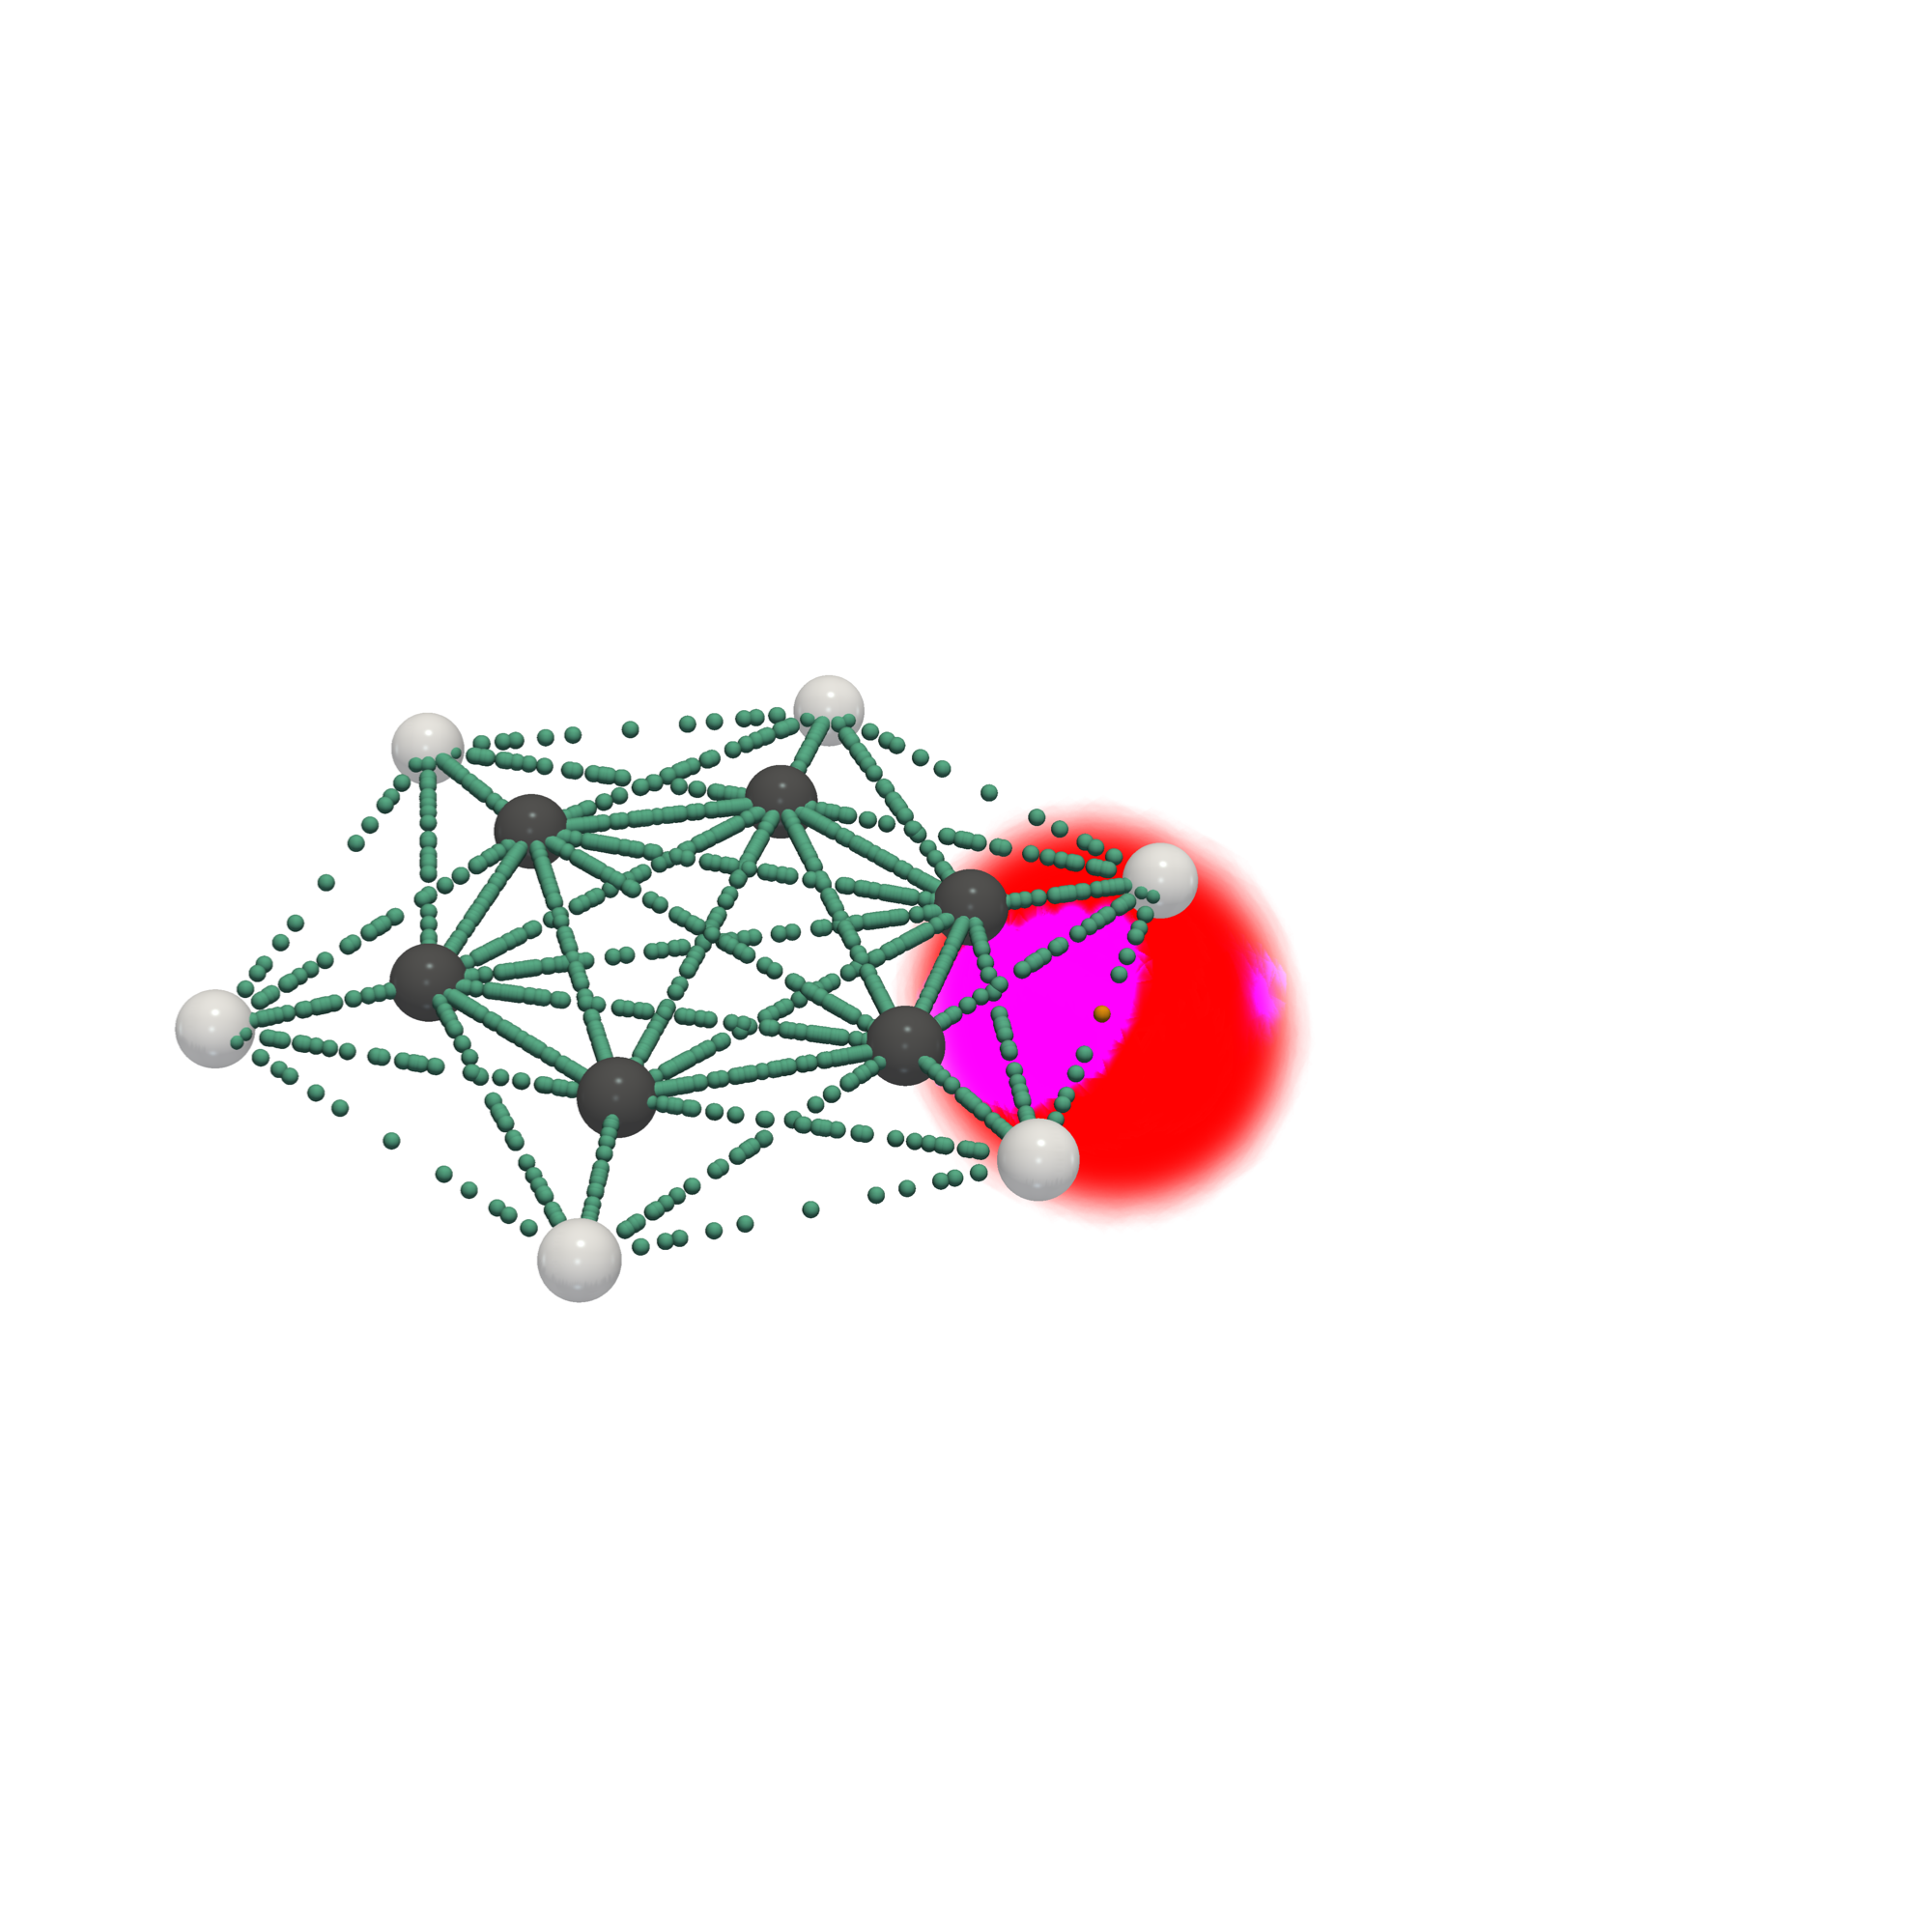


Gaussian product statistics:
Min value: -2.230839e-03
Max value: 5.672269e-05
Mean absolute value: 4.120086e-06
Non-zero values: 12472 / 125000


In [222]:
window_size = (2000, 2000)
# Compute 3D Gaussian product with higher resolution using full GTOs
# Using the maximum component approach for better visualization of directional character
gaussian_grid = compute_gaussian_product_3d(selected_peak_info, model.gto_dict, 
                                           grid_resolution=50, extent=3.0, use_all_orbitals=False)

pv.set_jupyter_backend('static')    # Static backend for better rendering

# Create high-quality visualization with advanced rendering
plotter = pv.Plotter(notebook=True, window_size=window_size)  # Higher resolution window

# Set advanced rendering options
plotter.enable_shadows()  # Enable shadows for depth perception
plotter.enable_anti_aliasing()  # Smooth edges

# Add molecular structure with enhanced colors
plotter.add_mesh(**get_atoms_only_mesh_dict(sample, atom_radius=0.2, resolution=40))  # Higher sphere resolution

# Add all peaks in sophisticated purple/magenta (instead of red)
plotter.add_points(peaks.numpy(), color='#60bc9cff', point_size=40, render_points_as_spheres=True, 
                  metallic=0., roughness=0.4)  # Sophisticated red with material properties

# Add selected peak in bright gold (instead of yellow)
plotter.add_points(selected_peak_pos.numpy().reshape(1, -1), color='#f39c12', point_size=40, 
                  render_points_as_spheres=True, metallic=0., roughness=0.2)  # Gold with metallic finish

# Add Gaussian product as volume with improved visibility
gaussian_values = gaussian_grid["gaussian_product"]

# Normalize Gaussian values with better contrast
# gaussian_normalized = np.abs(gaussian_values)
# gaussian_max = gaussian_normalized.max()
# if gaussian_max > 0:
#     gaussian_normalized = gaussian_normalized / gaussian_max

# Create RGBA values with improved blue color scheme
rgba = np.zeros((gaussian_grid.n_points, 4), np.uint8)

# Enhanced blue color scheme with better intensity gradation
# Use a deeper, more saturated blue that will be more visible
# base_color = np.array([0, 100, 255])  # Deep blue (instead of cyan-blue)

# color_intensity = gaussian_values
# for i in range(3):  # RGB channels
#     rgba[:, i] = base_color[i].astype(np.uint8)

# # normalize opacity, such that 0.1 quantile is fully opaque
# opac = np.abs(gaussian_values) ** 2
# opac /= find_isosurface_value(opac, 0.25, p=1)
# opac = np.clip(opac, 0, 1)

# rgba[:, -1] = opac * 255

# gaussian_grid["plot_scalars"] = rgba

neg_mask = gaussian_values < 0
# rgba = np.zeros((orbital.n_points, 4), np.uint8)
rgba[neg_mask, 0] = 170
rgba[~neg_mask, 2] = 170

# normalize opacity, such that 0.1 quantile is fully opaque
opac = np.abs(gaussian_values)  # ** 2
opac /= find_isosurface_value(opac, 0.25, p=1)
opac = np.clip(opac, 0, 1)

rgba[:, -1] = opac * 255

gaussian_grid["plot_scalars"] = rgba


# Add volume to plotter with improved settings
vol = plotter.add_volume(
    gaussian_grid,
    opacity_unit_distance=4,  # Reduced for denser appearance (was 6)
    scalars="plot_scalars",
)
vol.prop.interpolation_type = "linear"

# Set camera to an attractive angle
plotter.camera_position = 'iso'
plotter.camera.zoom(1.2)

plotter.show()
# Save with transparent background
# _ = plotter.screenshot('bonds_full_gtos.png', transparent_background=True, window_size=window_size)

print(f"\nGaussian product statistics:")
print(f"Min value: {gaussian_values.min():.6e}")
print(f"Max value: {gaussian_values.max():.6e}")
print(f"Mean absolute value: {np.abs(gaussian_values).mean():.6e}")
print(f"Non-zero values: {(np.abs(gaussian_values) > 1e-10).sum()} / {len(gaussian_values)}")

In [214]:
neg_mask.sum()

0

### Theory

When two Gaussian functions are multiplied:
- $G_1(r) = \exp(-\alpha_1 |r - R_1|^2)$ centered at $R_1$ with exponent $\alpha_1$
- $G_2(r) = \exp(-\alpha_2 |r - R_2|^2)$ centered at $R_2$ with exponent $\alpha_2$

Their product is also a Gaussian with peak located at:
$$R_{peak} = \frac{\alpha_1 R_1 + \alpha_2 R_2}{\alpha_1 + \alpha_2}$$

This represents the weighted average of the two centers, where the weights are the Gaussian exponents.


In [189]:
# Let's find a peak with higher angular momentum orbitals to better show the difference
print("Finding peaks with p-orbitals or higher angular momentum:")
print("=" * 60)

for i, info in enumerate(peak_info[:50]):  # Check first 50 peaks
    atom_i_type = info['atom_i_type']
    atom_j_type = info['atom_j_type']
    basis_i_idx = info['basis_i_idx']
    basis_j_idx = info['basis_j_idx']
    
    # Get GTO info
    gto_i = model.gto_dict[str(atom_i_type)]
    gto_j = model.gto_dict[str(atom_j_type)]
    L_i = gto_i.Ls[basis_i_idx].item()
    L_j = gto_j.Ls[basis_j_idx].item()
    
    # Look for interactions involving p-orbitals (L=1) or higher
    if L_i >= 1 or L_j >= 1:
        print(f"Peak {i}: Atoms {atom_i_type}-{atom_j_type}, basis ({basis_i_idx},{basis_j_idx}), L=({L_i},{L_j})")
        
        # Test this peak
        if i == 0 or (L_i >= 1 and L_j >= 1):  # Take first one found or p-p interaction
            print(f"\nTesting peak {i} with L_i={L_i}, L_j={L_j}")
            
            # Compute both versions for this peak
            grid_radial_p = compute_gaussian_product_3d_radial_only(info, grid_resolution=25, extent=2.0)
            grid_full_gto_p = compute_gaussian_product_3d(info, model.gto_dict, grid_resolution=25, extent=2.0)
            
            radial_values_p = grid_radial_p["gaussian_product"]
            full_gto_values_p = grid_full_gto_p["gaussian_product"]
            
            print(f"Radial-only approach (p-orbitals):")
            print(f"  Min: {radial_values_p.min():.6e}, Max: {radial_values_p.max():.6e}")
            print(f"  Mean: {radial_values_p.mean():.6e}")
            
            print(f"Full GTO approach (p-orbitals):")
            print(f"  Min: {full_gto_values_p.min():.6e}, Max: {full_gto_values_p.max():.6e}")
            print(f"  Mean: {full_gto_values_p.mean():.6e}")
            
            correlation_p = np.corrcoef(radial_values_p, full_gto_values_p)[0, 1]
            print(f"Correlation: {correlation_p:.4f}")
            print(f"This demonstrates the importance of including spherical harmonics!")
            break

print(f"\nSummary:")
print(f"========")
print(f"The improved compute_gaussian_product_3d function now:")
print(f"✓ Uses the full GTO computation including spherical harmonics")
print(f"✓ Applies proper normalization and radial corrections")
print(f"✓ Handles different angular momentum quantum numbers correctly")
print(f"✓ Provides more accurate orbital overlap visualization")
print(f"✓ Can select specific orbital components for directional bonds")

Finding peaks with p-orbitals or higher angular momentum:
Peak 7: Atoms 1-6, basis (0,7), L=(0,1)
Peak 8: Atoms 1-6, basis (0,8), L=(0,1)
Peak 9: Atoms 1-6, basis (0,9), L=(0,1)
Peak 10: Atoms 1-6, basis (0,10), L=(0,1)
Peak 11: Atoms 1-6, basis (0,11), L=(0,2)
Peak 19: Atoms 1-6, basis (1,7), L=(0,1)
Peak 20: Atoms 1-6, basis (1,8), L=(0,1)
Peak 21: Atoms 1-6, basis (1,9), L=(0,1)
Peak 22: Atoms 1-6, basis (1,10), L=(0,1)
Peak 23: Atoms 1-6, basis (1,11), L=(0,2)
Peak 31: Atoms 1-6, basis (2,7), L=(0,1)
Peak 32: Atoms 1-6, basis (2,8), L=(0,1)
Peak 33: Atoms 1-6, basis (2,9), L=(0,1)
Peak 34: Atoms 1-6, basis (2,10), L=(0,1)
Peak 35: Atoms 1-6, basis (2,11), L=(0,2)
Peak 43: Atoms 1-6, basis (3,7), L=(0,1)
Peak 44: Atoms 1-6, basis (3,8), L=(0,1)
Peak 45: Atoms 1-6, basis (3,9), L=(0,1)
Peak 46: Atoms 1-6, basis (3,10), L=(0,1)
Peak 47: Atoms 1-6, basis (3,11), L=(0,2)
Peak 48: Atoms 1-6, basis (4,0), L=(1,0)
Peak 49: Atoms 1-6, basis (4,1), L=(1,0)

Summary:
The improved compute_gaus